# Point Source Refractor - NK=1600 Fast Benchmark

Loads `results_refraction_NK1600.npz` (produced by `python generate_results_refraction.py`).

| | |
|---|---|
| **Benchmark** | spherical-patch refraction (Figure 4) |
| **Cost** | $c(x,y) = -\log(1 - \kappa\,(x\cdot y))$, $\kappa=0.6$ |
| **Algorithm** | Sinkhorn divergence, cold-start |
| **Grid** | NK=1600 Halton QMC on upper hemisphere |
| **Source** | $\theta\in[\pi/12,\,\pi/3]$, $\phi\in[\pi/12,\,\pi/4]$ |
| **Target** | $\theta\in[\pi/10,\,\pi/5]$, $\phi\in[\pi/10,\,\pi/5]$ |

In [40]:
import os, sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401

matplotlib.rcParams.update({'font.size': 11})

sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from refracter.distributions import stereo_north
# ── Available density-pair NPZs (source → target), NK=1600 ───────────────────────
NPZ_FILE = os.path.join('..', 'results', 'results_refraction_uniform_uniform_NK1600.npz')
#NPZ_FILE = os.path.join('..', 'results', 'results_refraction_uniform_gaussian_NK1600.npz')
# NPZ_FILE = os.path.join('..', 'results', 'results_refraction_uniform_donut_NK1600.npz')
# NPZ_FILE = os.path.join('..', 'results', 'results_refraction_uniform_cross_NK1600.npz')
# NPZ_FILE = os.path.join('..', 'results', 'results_refraction_gaussian_uniform_NK1600.npz')
# NPZ_FILE = os.path.join('..', 'results', 'results_refraction_gaussian_gaussian_NK1600.npz')
# NPZ_FILE = os.path.join('..', 'results', 'results_refraction_gaussian_donut_NK1600.npz')
# NPZ_FILE = os.path.join('..', 'results', 'results_refraction_gaussian_cross_NK1600.npz')
# NPZ_FILE = os.path.join('..', 'results', 'results_refraction_donut_uniform_NK1600.npz')
# NPZ_FILE = os.path.join('..', 'results', 'results_refraction_donut_gaussian_NK1600.npz')
# NPZ_FILE = os.path.join('..', 'results', 'results_refraction_donut_donut_NK1600.npz')
# NPZ_FILE = os.path.join('..', 'results', 'results_refraction_donut_cross_NK1600.npz')
# NPZ_FILE = os.path.join('..', 'results', 'results_refraction_cross_uniform_NK1600.npz')
# NPZ_FILE = os.path.join('..', 'results', 'results_refraction_cross_gaussian_NK1600.npz')
# NPZ_FILE = os.path.join('..', 'results', 'results_refraction_cross_donut_NK1600.npz')
# NPZ_FILE = os.path.join('..', 'results', 'results_refraction_cross_cross_NK1600.npz')
# NPZ_FILE = os.path.join('..', 'results', 'results_refraction_example_NK1600.npz')  # donut src, cross tgt, large patches
# NPZ_FILE = os.path.join('..', 'results', 'results_refraction_example_NK1600.npz')  # ← ACTIVE
data = np.load(NPZ_FILE)

x      = data['x'];        y      = data['y']       # (1600, 3) clouds
p      = data['p'];        q      = data['q']       # normalised densities
f_raw  = data['f_raw'];    g_raw  = data['g_raw']   # Sinkhorn potentials (pre-subtraction)
f_id   = data['f_id'];     g_id   = data['g_id']    # identity biases (zeros when identity correction off)
f      = data['f'];        g      = data['g']       # corrected = f_raw - f_id (= f_raw when identity off)
R      = data['R'];        Ref    = data['Ref']     # refractor radii / surface
gc     = data['gc'];       fc     = data['fc']      # c-transforms: gc indexed over target, fc over source
Refc   = data['Refc']

X_MeshGrid = data['X_MeshGrid']             # (256, 256) source density image
Y_MeshGrid = data['Y_MeshGrid']             # (256, 256) target density image
grid_side  = data['grid_side']              # axis  linspace(-0.6, 0.6, 256)

Y_projected        = data['Y_projected']        # (K, 3) target support  (u,v,q)
Y_Pushed_projected = data['Y_Pushed_projected'] # (M, 3) push-forward    (u,v,q)
y_push_3d          = data['y_push_3d']          # (M, 3) 3D upper-hemisphere pushed pts

kappa  = float(data['kappa'])                   # refraction index κ

NK     = len(x)
mask_p = p > 0
mask_q = q > 0

# Detect whether the identity correction was run (f_id, g_id non-zero) or skipped
identity_used = bool(np.any(f_id != 0) or np.any(g_id != 0))

# Both patches are on the UPPER hemisphere → north-pole projection for both
u_x, v_x = stereo_north(x)
u_y, v_y = stereo_north(y)

print(f'NK={NK},  κ={kappa},  source support={mask_p.sum()},  target support={mask_q.sum()}')
print(f'identity correction: {"ON" if identity_used else "OFF"}')
print(f'R (all NK):    min={R.min():.4f}, max={R.max():.4f}')
print(f'R (supported): min={R[mask_p].min():.4f}, max={R[mask_p].max():.4f}, mean={R[mask_p].mean():.4f}')

NK=1600,  κ=0.6,  source support=1600,  target support=1600
identity correction: ON
R (all NK):    min=0.9646, max=1.0422
R (supported): min=0.9646, max=1.0422, mean=1.0142


## 1  Source & Target Distributions (2D stereographic projections)

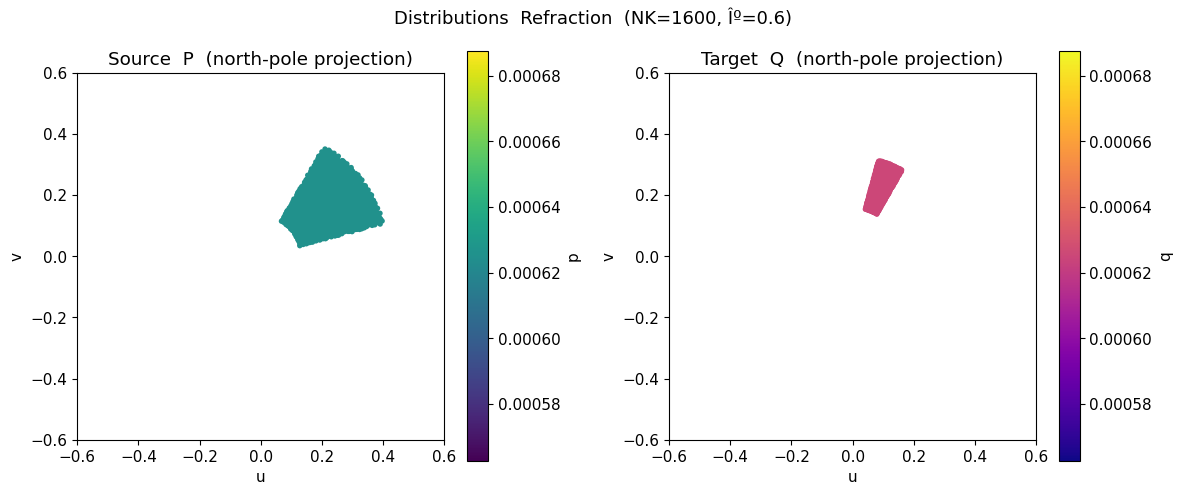

Saved fig_distributions.png


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sc0 = axes[0].scatter(u_x[mask_p], v_x[mask_p], c=p[mask_p],
                       cmap='viridis', s=15, edgecolors='none')
plt.colorbar(sc0, ax=axes[0], label='p')
axes[0].set_title('Source  P  (north-pole projection)')
axes[0].set_xlabel('u');  axes[0].set_ylabel('v')
axes[0].set_aspect('equal');  axes[0].set_xlim(-0.6, 0.6);  axes[0].set_ylim(-0.6, 0.6)

sc1 = axes[1].scatter(u_y[mask_q], v_y[mask_q], c=q[mask_q],
                       cmap='plasma', s=15, edgecolors='none')
plt.colorbar(sc1, ax=axes[1], label='q')
axes[1].set_title('Target  Q  (north-pole projection)')
axes[1].set_xlabel('u');  axes[1].set_ylabel('v')
axes[1].set_aspect('equal');  axes[1].set_xlim(-0.6, 0.6);  axes[1].set_ylim(-0.6, 0.6)

plt.suptitle(f'Distributions  Refraction  (NK={NK}, Îº={kappa})', fontsize=13)
plt.tight_layout()
plt.savefig('fig_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_distributions.png')

## 2  Refractor Surface (3D scatter)

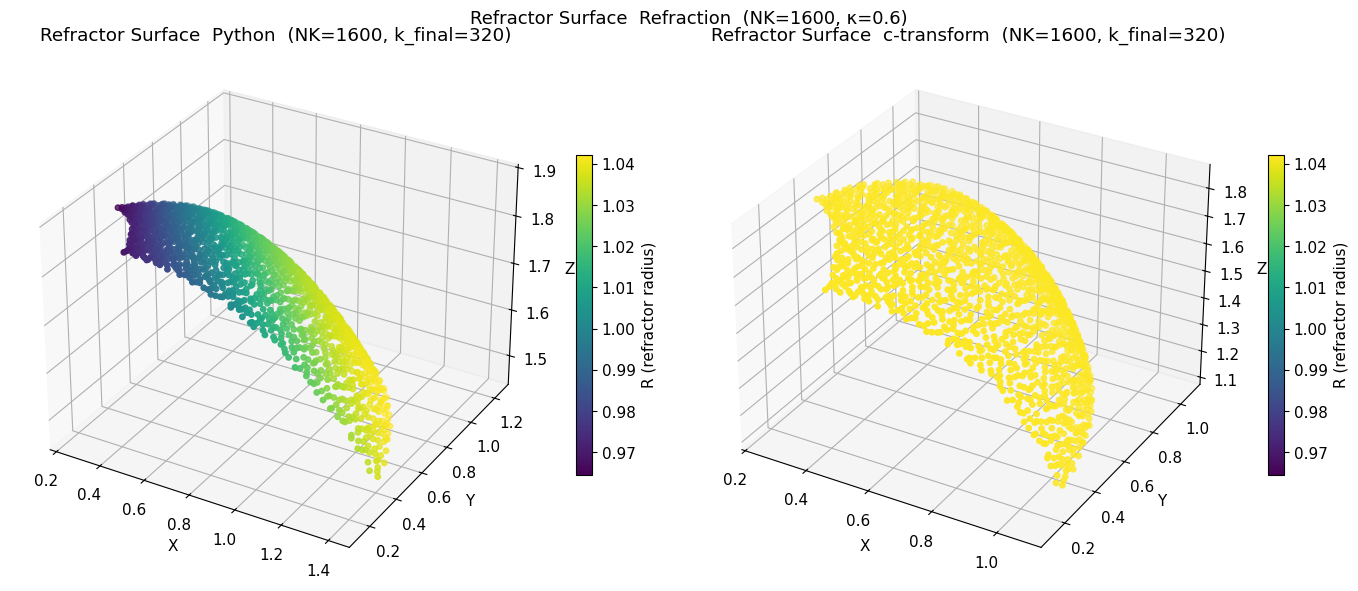

Saved fig_refractor_3d.png


In [42]:
vmin = R.min()   # full R range (all NK) for colour scale
vmax = R.max()
k_final = 8 * int(np.floor(np.sqrt(NK)))

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(Ref[:, 0], Ref[:, 1], Ref[:, 2],
                  c=R, cmap='viridis', s=15,
                  vmin=vmin, vmax=vmax, depthshade=True)
plt.colorbar(sc1, ax=ax1, label='R (refractor radius)', shrink=0.6)
ax1.set_title(f'Refractor Surface  Python  (NK={NK}, k_final={k_final})')
ax1.set_xlabel('X');  ax1.set_ylabel('Y');  ax1.set_zlabel('Z')

# Refc = 2*x*exp(fc); fc is source-indexed (c-conjugate of g), matching x.
ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(Refc[:, 0], Refc[:, 1], Refc[:, 2],
                  c=np.exp(fc), cmap='viridis', s=15,
                  vmin=vmin, vmax=vmax, depthshade=True)
plt.colorbar(sc2, ax=ax2, label='R (refractor radius)', shrink=0.6)
ax2.set_title(f'Refractor Surface  c-transform  (NK={NK}, k_final={k_final})')
ax2.set_xlabel('X');  ax2.set_ylabel('Y');  ax2.set_zlabel('Z')

fig.suptitle(f'Refractor Surface  Refraction  (NK={NK}, κ={kappa})', fontsize=13)
plt.tight_layout()
plt.savefig('fig_refractor_3d.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved fig_refractor_3d.png')

## 3  Kantorovich Potentials (2D projections)

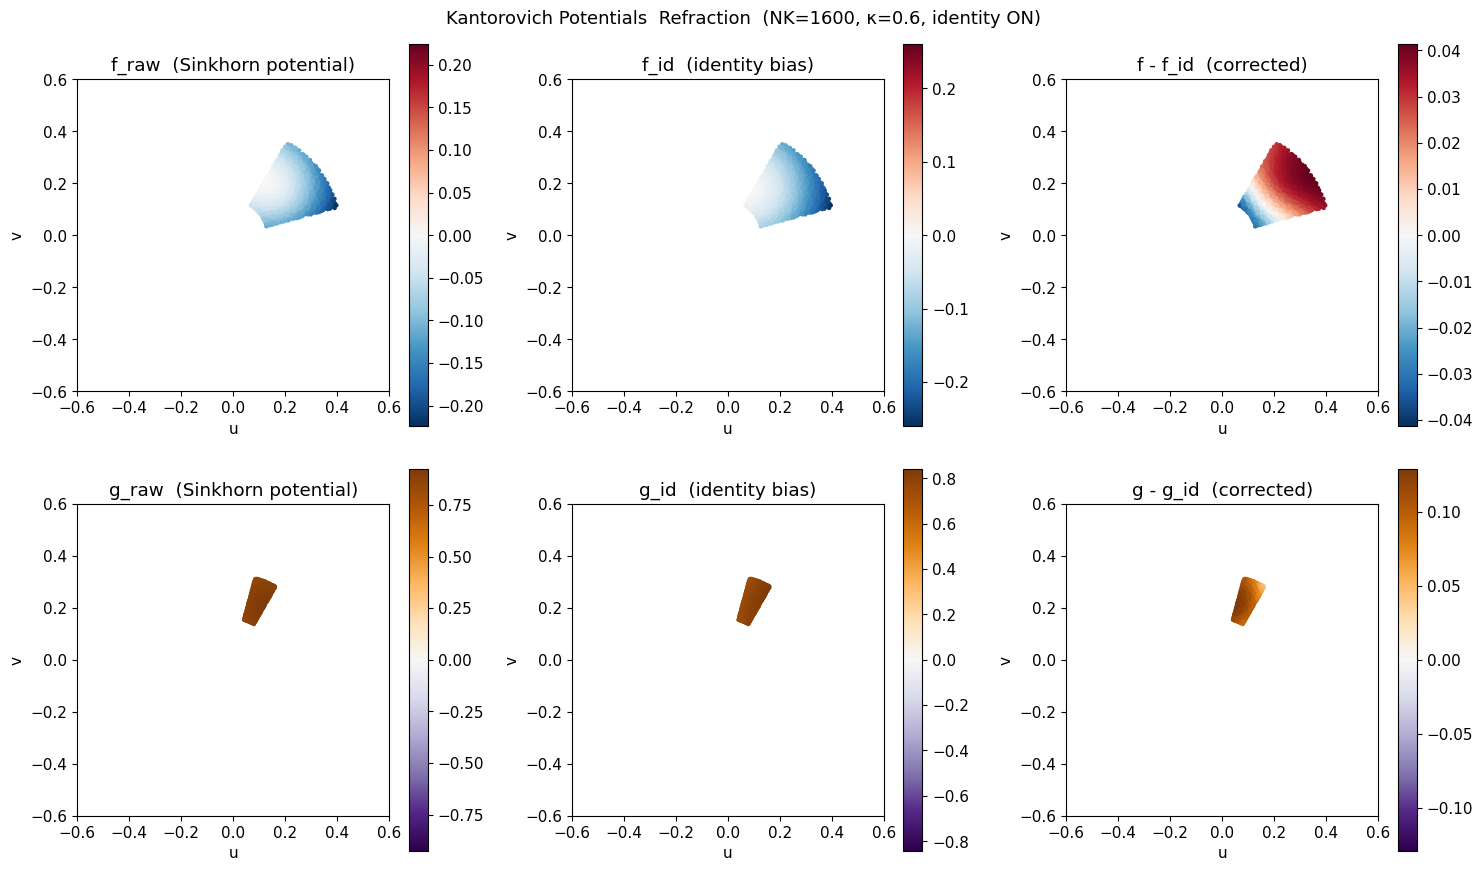

Saved fig_potentials.png


In [43]:
if identity_used:
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))

    src_panels = [
        (f_raw,          'f_raw  (Sinkhorn potential)', 'RdBu_r'),
        (f_id,           'f_id  (identity bias)',       'RdBu_r'),
        (f_raw - f_id,   'f - f_id  (corrected)',       'RdBu_r'),
    ]
    tgt_panels = [
        (g_raw,          'g_raw  (Sinkhorn potential)', 'PuOr_r'),
        (g_id,           'g_id  (identity bias)',       'PuOr_r'),
        (g_raw - g_id,   'g - g_id  (corrected)',       'PuOr_r'),
    ]
else:
    # Identity correction off: f_id = g_id = 0, so the corrected potentials
    # are just f_raw / g_raw. Show them once.
    fig, axes = plt.subplots(2, 1, figsize=(6, 9), squeeze=False)
    src_panels = [(f_raw, 'f_raw  (Sinkhorn potential)', 'RdBu_r')]
    tgt_panels = [(g_raw, 'g_raw  (Sinkhorn potential)', 'PuOr_r')]

for col, (arr, title, cmap) in enumerate(src_panels):
    ax   = axes[0, col]
    vals = arr[mask_p]
    lim  = np.abs(vals).max() if vals.size else 1.0
    sc   = ax.scatter(u_x[mask_p], v_x[mask_p], c=vals,
                      cmap=cmap, s=10, vmin=-lim, vmax=lim, edgecolors='none')
    plt.colorbar(sc, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('u');  ax.set_ylabel('v')
    ax.set_aspect('equal');  ax.set_xlim(-0.6, 0.6);  ax.set_ylim(-0.6, 0.6)

for col, (arr, title, cmap) in enumerate(tgt_panels):
    ax   = axes[1, col]
    vals = arr[mask_q]
    lim  = np.abs(vals).max() if vals.size else 1.0
    sc   = ax.scatter(u_y[mask_q], v_y[mask_q], c=vals,
                      cmap=cmap, s=10, vmin=-lim, vmax=lim, edgecolors='none')
    plt.colorbar(sc, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('u');  ax.set_ylabel('v')
    ax.set_aspect('equal');  ax.set_xlim(-0.6, 0.6);  ax.set_ylim(-0.6, 0.6)

id_tag = 'identity ON' if identity_used else 'identity OFF'
plt.suptitle(f'Kantorovich Potentials  Refraction  (NK={NK}, κ={kappa}, {id_tag})', fontsize=13)
plt.tight_layout()
plt.savefig('fig_potentials.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_potentials.png')

## 4  C-Transform Residuals
At convergence $f = g^c$ and $g = f^c$.  Residuals below show how close we are.

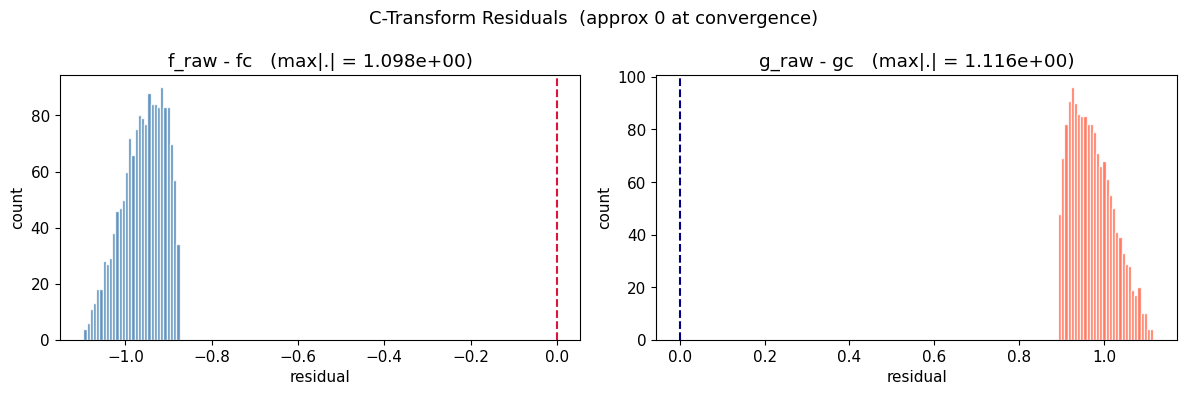

max|f_raw-fc| = 1.0977e+00
max|g_raw-gc| = 1.1164e+00
Saved fig_ctransform_residuals.png


In [44]:
# C-transform residuals check OT convergence:
#   fc[i] = min_j (C(x_i,y_j) - g_raw[j])  ≈ f_raw[i] at convergence  (source-indexed)
#   gc[j] = min_i (C(x_i,y_j) - f_raw[i])  ≈ g_raw[j] at convergence  (target-indexed)
res_f = f_raw[mask_p] - fc[mask_p]
res_g = g_raw[mask_q] - gc[mask_q]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(res_f, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='crimson', linewidth=1.5, linestyle='--')
axes[0].set_title(f'f_raw - fc   (max|.| = {np.abs(res_f).max():.3e})')
axes[0].set_xlabel('residual');  axes[0].set_ylabel('count')

axes[1].hist(res_g, bins=30, color='tomato', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='navy', linewidth=1.5, linestyle='--')
axes[1].set_title(f'g_raw - gc   (max|.| = {np.abs(res_g).max():.3e})')
axes[1].set_xlabel('residual');  axes[1].set_ylabel('count')

plt.suptitle('C-Transform Residuals  (approx 0 at convergence)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_ctransform_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'max|f_raw-fc| = {np.abs(res_f).max():.4e}')
print(f'max|g_raw-gc| = {np.abs(res_g).max():.4e}')
print('Saved fig_ctransform_residuals.png')

## 5  Six-panel overview
Source density Â· target density Â· target scatter Â· pushed scatter Â· refractor 3D Â· overlay

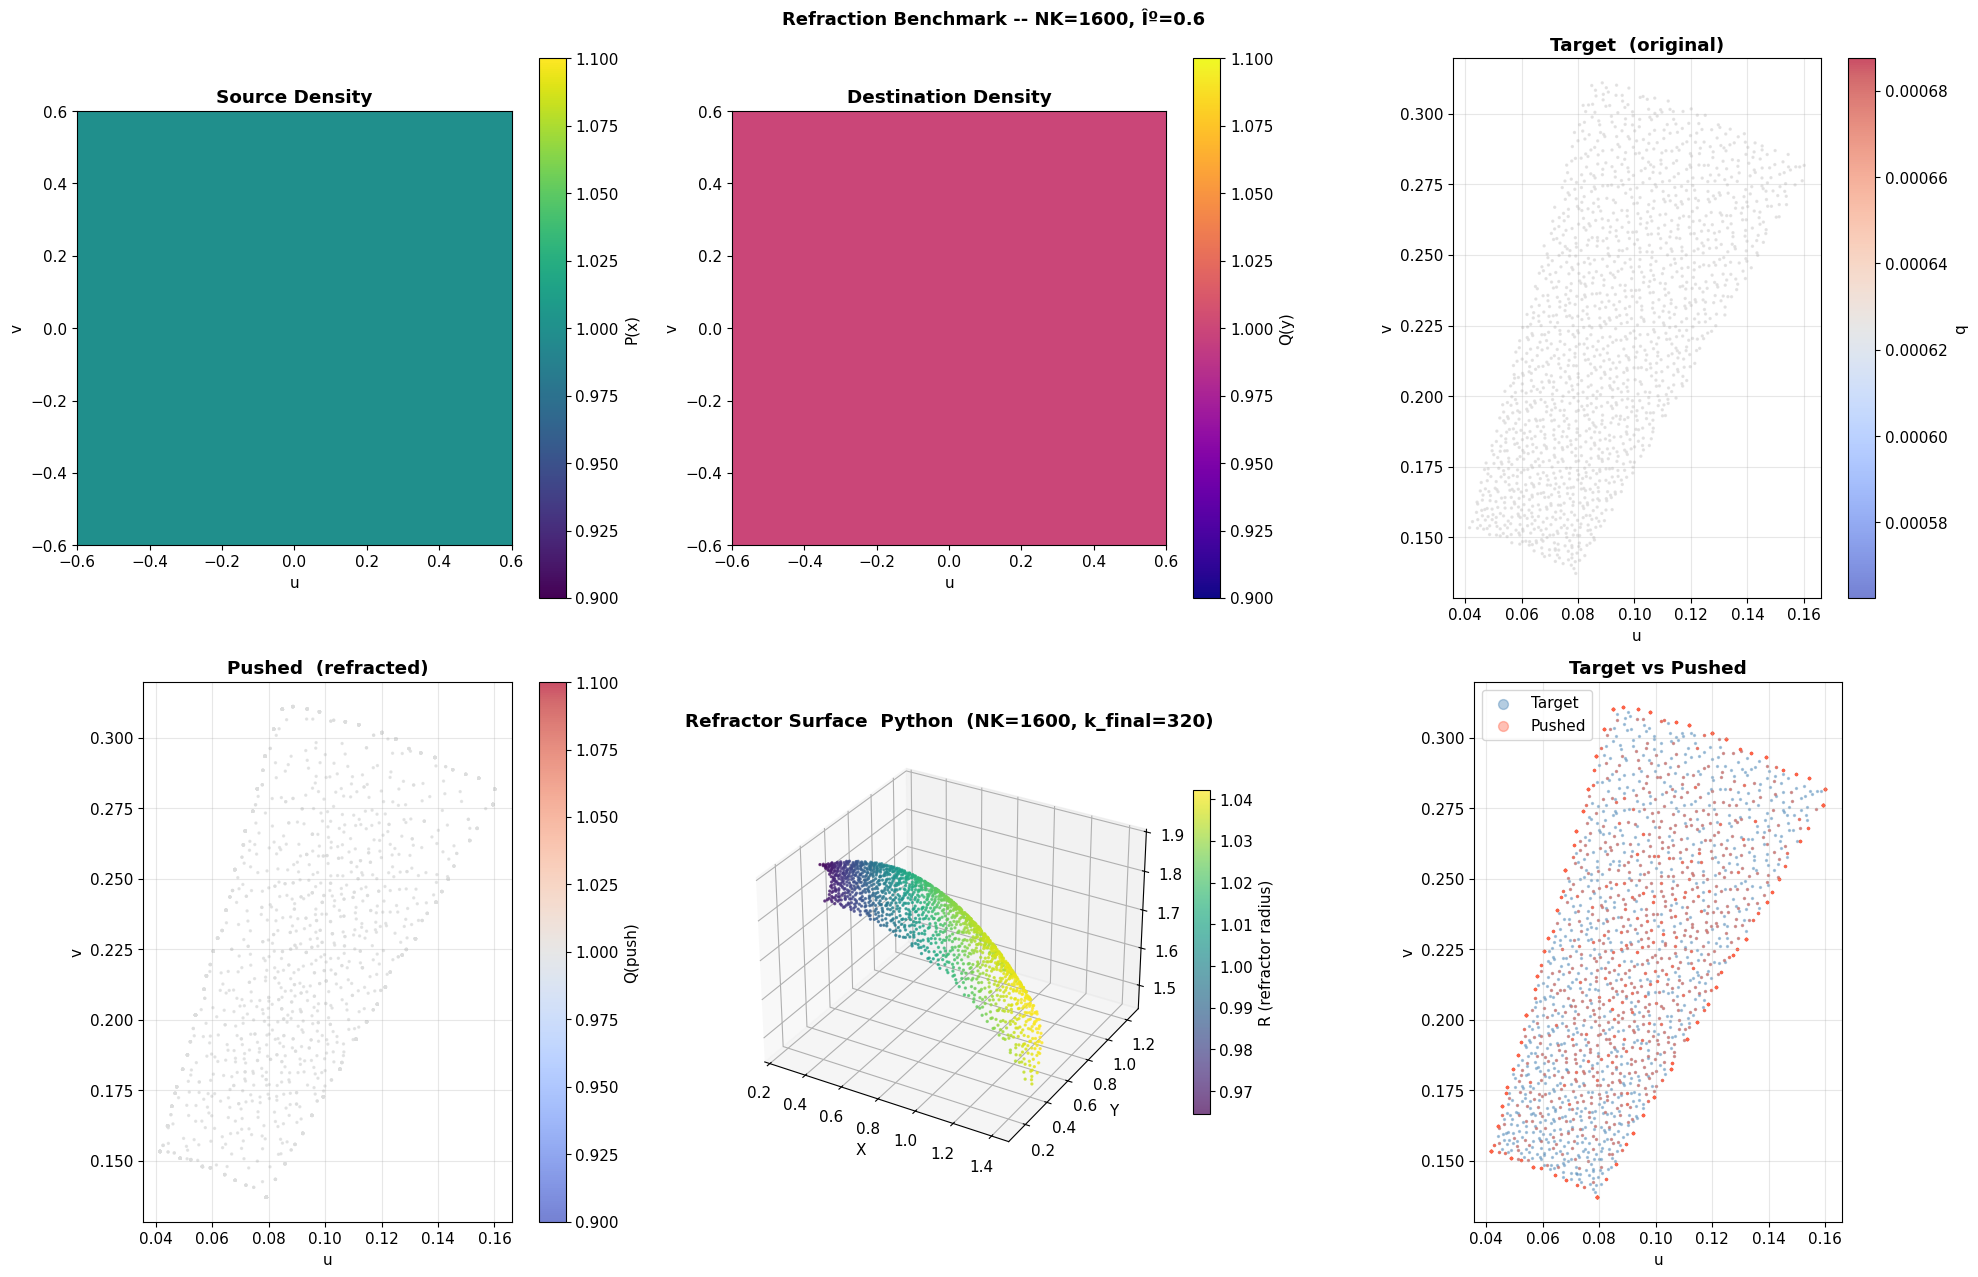

Saved fig_visualization.png


In [45]:
ext = [-0.6, 0.6, -0.6, 0.6]   # extent for imshow
k_final = 8 * int(np.floor(np.sqrt(NK)))

fig = plt.figure(figsize=(20, 13))
fig.suptitle(
    f'Refraction Benchmark -- NK={NK}, Îº={kappa}',
    fontsize=13, fontweight='bold',
)

# â”€â”€ Panel 1: Source Density (meshgrid imshow) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ax = plt.subplot(2, 3, 1)
im = ax.imshow(X_MeshGrid.T, extent=ext, origin='lower', cmap='viridis', aspect='equal')
plt.colorbar(im, ax=ax, label='P(x)')
ax.set_title('Source Density', fontweight='bold')
ax.set_xlabel('u');  ax.set_ylabel('v')

# â”€â”€ Panel 2: Destination Density (meshgrid imshow) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ax = plt.subplot(2, 3, 2)
im = ax.imshow(Y_MeshGrid.T, extent=ext, origin='lower', cmap='plasma', aspect='equal')
plt.colorbar(im, ax=ax, label='Q(y)')
ax.set_title('Destination Density', fontweight='bold')
ax.set_xlabel('u');  ax.set_ylabel('v')

# â”€â”€ Panel 3: Target distribution (original scatter) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ax = plt.subplot(2, 3, 3)
sc = ax.scatter(Y_projected[:, 0], Y_projected[:, 1], c=Y_projected[:, 2],
                cmap='coolwarm', s=2, alpha=0.7)
plt.colorbar(sc, ax=ax, label='q')
ax.set_title('Target  (original)', fontweight='bold')
ax.set_xlabel('u');  ax.set_ylabel('v')
ax.set_aspect('equal');  ax.grid(True, alpha=0.3)

# â”€â”€ Panel 4: Pushed / refracted distribution â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ax = plt.subplot(2, 3, 4)
sc = ax.scatter(Y_Pushed_projected[:, 0], Y_Pushed_projected[:, 1],
                c=Y_Pushed_projected[:, 2], cmap='coolwarm', s=2, alpha=0.7)
plt.colorbar(sc, ax=ax, label='Q(push)')
ax.set_title('Pushed  (refracted)', fontweight='bold')
ax.set_xlabel('u');  ax.set_ylabel('v')
ax.set_aspect('equal');  ax.grid(True, alpha=0.3)

# â”€â”€ Panel 5: Refractor Surface (3D scatter, all NK points) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ax = plt.subplot(2, 3, 5, projection='3d')
sc5 = ax.scatter(Ref[:, 0], Ref[:, 1], Ref[:, 2],
                 s=2, alpha=0.7, c=R, cmap='viridis',
                 vmin=R.min(), vmax=R.max())
plt.colorbar(sc5, ax=ax, label='R (refractor radius)', shrink=0.6)
ax.set_title(f'Refractor Surface  Python  (NK={NK}, k_final={k_final})', fontweight='bold')
ax.set_xlabel('X');  ax.set_ylabel('Y');  ax.set_zlabel('Z')

# â”€â”€ Panel 6: Target vs Pushed overlay â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ax = plt.subplot(2, 3, 6)
ax.scatter(Y_projected[:, 0],        Y_projected[:, 1],
           s=2, alpha=0.4, label='Target',  color='steelblue')
ax.scatter(Y_Pushed_projected[:, 0], Y_Pushed_projected[:, 1],
           s=2, alpha=0.4, label='Pushed', color='tomato')
ax.legend(markerscale=5);  ax.set_aspect('equal');  ax.grid(True, alpha=0.3)
ax.set_title('Target vs Pushed', fontweight='bold')
ax.set_xlabel('u');  ax.set_ylabel('v')

plt.tight_layout()
plt.savefig('fig_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_visualization.png')

## 6  Radius Analysis

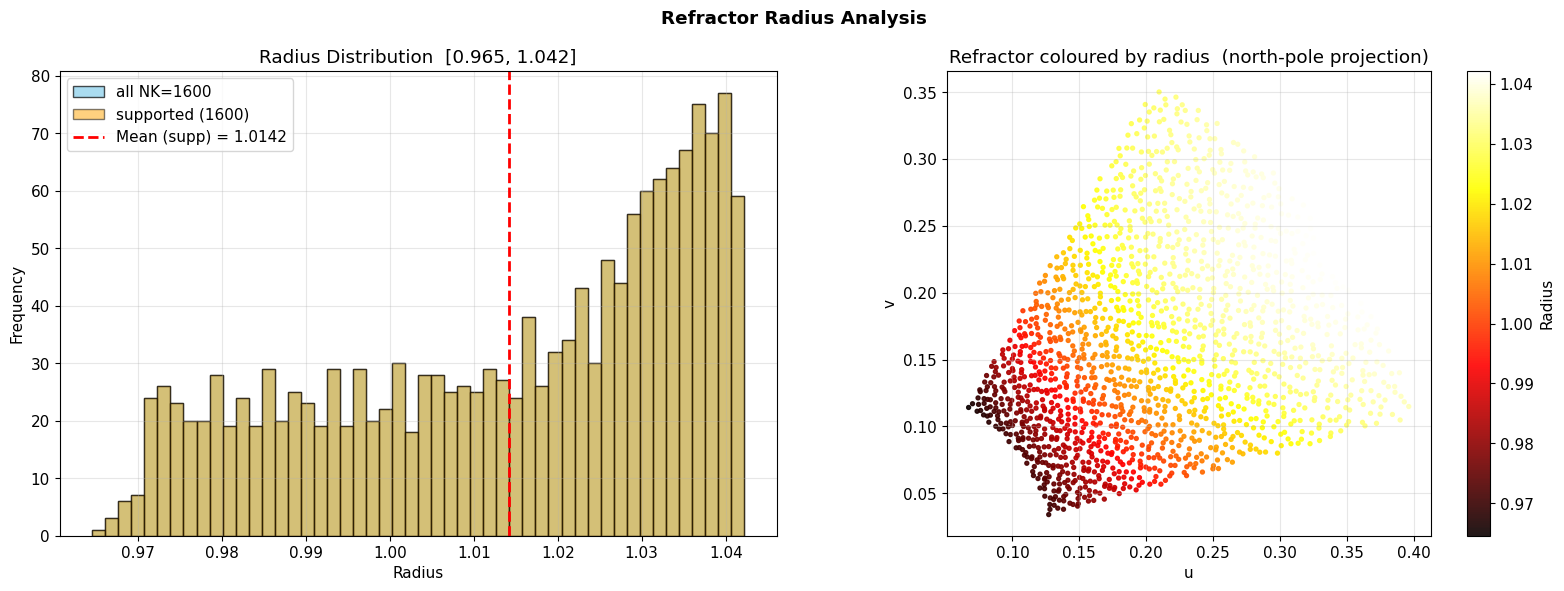

Saved fig_refractor_analysis.png


In [46]:
R_all  = R                 # all NK radii (including unsupported)
R_supp = R[mask_p]         # supported-only subset

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Refractor Radius Analysis', fontweight='bold')

# Histogram  all NK points to show full range [min_unsup, max_supp]
axes[0].hist(R_all, bins=50, edgecolor='black', alpha=0.7, color='skyblue', label=f'all NK={NK}')
axes[0].hist(R_supp, bins=50, edgecolor='black', alpha=0.5, color='orange', label=f'supported ({mask_p.sum()})')
axes[0].axvline(R_supp.mean(), color='red', ls='--', lw=2,
                label=f'Mean (supp) = {R_supp.mean():.4f}')
axes[0].legend()
axes[0].set_title(f'Radius Distribution  [{R_all.min():.3f}, {R_all.max():.3f}]')
axes[0].set_xlabel('Radius');  axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# Scatter coloured by R (north-pole projection, supported only)
sc = axes[1].scatter(u_x[mask_p], v_x[mask_p], c=R_supp, cmap='hot', s=8, alpha=0.9)
plt.colorbar(sc, ax=axes[1], label='Radius')
axes[1].set_aspect('equal');  axes[1].grid(True, alpha=0.3)
axes[1].set_title('Refractor coloured by radius  (north-pole projection)')
axes[1].set_xlabel('u');  axes[1].set_ylabel('v')

plt.tight_layout()
plt.savefig('fig_refractor_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_refractor_analysis.png')

## 7 - Interactive 3D Optical System *(Plotly)*

Drag = rotate  |  Scroll = zoom  |  Hover = values  
Click legend items to toggle traces on/off.

In [47]:
import subprocess, importlib

try:
    import plotly.graph_objects as go
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'plotly', '--quiet'], check=True)
    importlib.invalidate_caches()
    import plotly.graph_objects as go

MAX_PTS = 6_000
rng     = np.random.default_rng(42)

fig3d = go.Figure()

# â”€â”€ 1. Source hemisphere: scatter coloured by P(x) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
src_idx = np.where(mask_p)[0]
si      = rng.choice(len(src_idx), min(len(src_idx), MAX_PTS), replace=False)
s_pts   = x[src_idx[si]];  s_col = p[src_idx[si]]
fig3d.add_trace(go.Scatter3d(
    x=s_pts[:, 0], y=s_pts[:, 1], z=s_pts[:, 2],
    mode='markers',
    marker=dict(size=2.5, color=s_col, colorscale='YlOrRd', opacity=0.65, showscale=False),
    name='Source  P(x)',
    hovertemplate='x=%{x:.3f}  y=%{y:.3f}  z=%{z:.3f}<br>P=%{marker.color:.4f}<extra></extra>',
))

# â”€â”€ 2. Refractor surface: scatter coloured by radius â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ref_idx = np.where(mask_p)[0]
ri      = rng.choice(len(ref_idx), min(len(ref_idx), MAX_PTS), replace=False)
ref_pts = Ref[ref_idx[ri]];  r_col = R[ref_idx[ri]]
fig3d.add_trace(go.Scatter3d(
    x=ref_pts[:, 0], y=ref_pts[:, 1], z=ref_pts[:, 2],
    mode='markers',
    marker=dict(size=3, color=r_col, colorscale='Viridis', opacity=0.85,
                showscale=True,
                colorbar=dict(title='Radius', x=1.02, len=0.55, y=0.5, thickness=15)),
    name='Refractor surface',
    hovertemplate='x=%{x:.3f}  y=%{y:.3f}  z=%{z:.3f}<br>R=%{marker.color:.4f}<extra></extra>',
))

# â”€â”€ 3. Output light: push-forward on upper hemisphere â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
n_push = len(y_push_3d)
pi     = rng.choice(n_push, min(n_push, MAX_PTS), replace=False)
push_col = Y_Pushed_projected[pi, 2]   # Q(y_pushed)
fig3d.add_trace(go.Scatter3d(
    x=y_push_3d[pi, 0], y=y_push_3d[pi, 1], z=y_push_3d[pi, 2],
    mode='markers',
    marker=dict(size=2.5, color=push_col, colorscale='Blues', opacity=0.65, showscale=False),
    name='Output light  Q(y)',
    hovertemplate='x=%{x:.3f}  y=%{y:.3f}  z=%{z:.3f}<br>Q=%{marker.color:.4f}<extra></extra>',
))

fig3d.update_layout(
    title=dict(
        text=(
            '<b>Optical System -- Refraction</b><br>'
            f'<sup>NK={NK}  \u00b7  \u03ba={kappa}  \u00b7  '
            'source P(x)  \u00b7  refractor (radius)  \u00b7  output Q(y)  \u00b7  '
            'drag=rotate  scroll=zoom  hover=values</sup>'
        ),
        x=0.5, xanchor='center',
    ),
    scene=dict(
        xaxis=dict(title='X', showgrid=True),
        yaxis=dict(title='Y', showgrid=True),
        zaxis=dict(title='Z', showgrid=True),
        aspectmode='data',
        camera=dict(eye=dict(x=1.4, y=1.4, z=0.8)),
    ),
    legend=dict(itemsizing='constant', x=0, y=1),
    margin=dict(l=0, r=80, t=100, b=0),
    width=960, height=720,
)

html_path = 'fig_optical_3d.html'
fig3d.write_html(html_path, include_plotlyjs='cdn')
from IPython.display import HTML, display as _display
_display(HTML(filename=html_path))
print(f'Interactive 3D plot saved to {html_path}')

Interactive 3D plot saved to fig_optical_3d.html


## 7b - Interactive 3D Optical System *(Surface Mesh)*

Refractor rendered as a triangulated mesh via **Delaunay triangulation in $(\theta, \phi)$ space** - the most efficient algorithm for quasi-random scattered points on a spherical patch.  
Source P(x) and output Q(y) remain as scatter points (same style as Section 7).  
Drag = rotate  |  Scroll = zoom  |  Hover = values

In [48]:
from scipy.spatial import Delaunay

# â”€â”€ Triangulate refractor surface in (Î¸, Ï†) space â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Since Ref[i] = R[i] * x[i] (same angular structure as source directions),
# we recover spherical coordinates from x (unit vectors) and triangulate there.
theta = np.arccos(np.clip(x[:, 2], -1.0, 1.0))   # polar angle
phi   = np.arctan2(x[:, 1], x[:, 0])               # azimuthal angle

theta_m = theta[mask_p]
phi_m   = phi[mask_p]

tri       = Delaunay(np.column_stack([theta_m, phi_m]))
triangles = tri.simplices   # (N_tri, 3) indices into the masked arrays

# Filter long boundary sliver triangles (Delaunay convex-hull artefacts)
pts2d     = np.column_stack([theta_m, phi_m])
max_edges = np.array([
    max(np.linalg.norm(pts2d[a] - pts2d[b]),
        np.linalg.norm(pts2d[b] - pts2d[c]),
        np.linalg.norm(pts2d[c] - pts2d[a]))
    for a, b, c in triangles
])
thresh          = np.median(max_edges) * 3.0
triangles_clean = triangles[max_edges < thresh]
print(f'Triangles: {len(triangles)} total â†’ {len(triangles_clean)} after sliver filter')

fig3d_surf = go.Figure()

# â”€â”€ 1. Source hemisphere: scatter coloured by P(x) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
src_idx2 = np.where(mask_p)[0]
rng2     = np.random.default_rng(42)
si2      = rng2.choice(len(src_idx2), min(len(src_idx2), MAX_PTS), replace=False)
s_pts2   = x[src_idx2[si2]];  s_col2 = p[src_idx2[si2]]
fig3d_surf.add_trace(go.Scatter3d(
    x=s_pts2[:, 0], y=s_pts2[:, 1], z=s_pts2[:, 2],
    mode='markers',
    marker=dict(size=2.5, color=s_col2, colorscale='YlOrRd', opacity=0.65, showscale=False),
    name='Source  P(x)',
    hovertemplate='x=%{x:.3f}  y=%{y:.3f}  z=%{z:.3f}<br>P=%{marker.color:.4f}<extra></extra>',
))

# â”€â”€ 2. Refractor surface mesh (Delaunay triangulation in Î¸,Ï†) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ref_pts_m = Ref[mask_p]
r_col_m   = R[mask_p]
fig3d_surf.add_trace(go.Mesh3d(
    x=ref_pts_m[:, 0], y=ref_pts_m[:, 1], z=ref_pts_m[:, 2],
    i=triangles_clean[:, 0],
    j=triangles_clean[:, 1],
    k=triangles_clean[:, 2],
    intensity=r_col_m,
    colorscale='Viridis',
    opacity=0.85,
    showscale=True,
    colorbar=dict(title='Radius', x=1.02, len=0.55, y=0.5, thickness=15),
    name='Refractor surface',
    hovertemplate='x=%{x:.3f}  y=%{y:.3f}  z=%{z:.3f}<br>R=%{intensity:.4f}<extra></extra>',
))

# â”€â”€ 3. Output light: push-forward on upper hemisphere â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
n_push2  = len(y_push_3d)
pi2      = rng2.choice(n_push2, min(n_push2, MAX_PTS), replace=False)
push_col2 = Y_Pushed_projected[pi2, 2]
fig3d_surf.add_trace(go.Scatter3d(
    x=y_push_3d[pi2, 0], y=y_push_3d[pi2, 1], z=y_push_3d[pi2, 2],
    mode='markers',
    marker=dict(size=2.5, color=push_col2, colorscale='Blues', opacity=0.65, showscale=False),
    name='Output light  Q(y)',
    hovertemplate='x=%{x:.3f}  y=%{y:.3f}  z=%{z:.3f}<br>Q=%{marker.color:.4f}<extra></extra>',
))

fig3d_surf.update_layout(
    title=dict(
        text=(
            '<b>Optical System -- Refraction (Surface Mesh)</b><br>'
            f'<sup>NK={NK}  Â·  Îº={kappa}  Â·  '
            'source P(x)  Â·  refractor mesh (Delaunay in Î¸,Ï†)  Â·  output Q(y)  Â·  '
            'drag=rotate  scroll=zoom  hover=values</sup>'
        ),
        x=0.5, xanchor='center',
    ),
    scene=dict(
        xaxis=dict(title='X', showgrid=True),
        yaxis=dict(title='Y', showgrid=True),
        zaxis=dict(title='Z', showgrid=True),
        aspectmode='data',
        camera=dict(eye=dict(x=1.4, y=1.4, z=0.8)),
    ),
    legend=dict(itemsizing='constant', x=0, y=1),
    margin=dict(l=0, r=80, t=100, b=0),
    width=960, height=720,
)

html_path_surf = 'fig_optical_3d_surface.html'
fig3d_surf.write_html(html_path_surf, include_plotlyjs='cdn')
from IPython.display import HTML, display as _display
_display(HTML(filename=html_path_surf))
print(f'Interactive 3D surface plot saved to {html_path_surf}')

Triangles: 3181 total â†’ 3135 after sliver filter


Interactive 3D surface plot saved to fig_optical_3d_surface.html


## 8  Summary Statistics

In [49]:
k_final    = 8 * int(np.floor(np.sqrt(NK)))
total_cost = float(np.sum(p[mask_p]*f[mask_p]) + np.sum(q[mask_q]*g[mask_q]))

print('=' * 58)
print(f'  Benchmark       : Refraction (Figure 4)')
print(f'  Cost function   : c(x,y) = -log(1 - {kappa}*(x.y))')
print(f'  κ               : {kappa}')
print(f'  NK              : {NK}')
print(f'  Identity correc.: {"ON" if identity_used else "OFF"}')
print(f'  Source support  : {mask_p.sum()} / {NK} points')
print(f'  Target support  : {mask_q.sum()} / {NK} points')
print(f'  k_final         : {k_final}')
print(f'  Total cost      : {total_cost:.6e}')
print(f'  R range (all)   : [{R.min():.4f}, {R.max():.4f}]')
print(f'  R range (supp)  : [{R[mask_p].min():.4f}, {R[mask_p].max():.4f}]')
print(f'  R mean (supp)   : {R[mask_p].mean():.4f}')
print(f'  max|f_raw-fc|   : {np.abs(f_raw[mask_p]-fc[mask_p]).max():.4e}')
print(f'  max|g_raw-gc|   : {np.abs(g_raw[mask_q]-gc[mask_q]).max():.4e}')
print(f'  Push-forward    : {len(y_push_3d)} source points mapped')
print('=' * 58)

  Benchmark       : Refraction (Figure 4)
  Cost function   : c(x,y) = -log(1 - 0.6*(x.y))
  κ               : 0.6
  NK              : 1600
  Identity correc.: ON
  Source support  : 1600 / 1600 points
  Target support  : 1600 / 1600 points
  k_final         : 320
  Total cost      : 1.204576e-01
  R range (all)   : [0.9646, 1.0422]
  R range (supp)  : [0.9646, 1.0422]
  R mean (supp)   : 1.0142
  max|f_raw-fc|   : 1.0977e+00
  max|g_raw-gc|   : 1.1164e+00
  Push-forward    : 1600 source points mapped


## 9 - Entropic Interpolation of the Refractor Surface

Uses **Definition 3** (Entropic interpolation) to continuously extend the Sinkhorn
potential $\tilde{f}^{OT_\varepsilon}$ to a dense grid:

$$\tilde{f}^{OT_\varepsilon}(x) := -\varepsilon\,\log\!\sum_{j=1}^{N}
\exp\!\left(\frac{1}{\varepsilon}\bigl(g^{OT_\varepsilon}(y_j) - c(x,y_j)\bigr)\right)
\nu_N(y_j)$$

where $\varepsilon = 1/k_{\mathrm{final}}$ and the sum runs over the **target support**.
The identity bias $\tilde{f}_{\mathrm{id}}$ is extended by the same formula using $f_{\mathrm{id}}$
as the dual potential on the $y$-side with source weights $p$.
The smooth refractor radius is then $\tilde{R}(x)=\exp(\tilde{f} - \tilde{f}_{\mathrm{id}})$.

In [50]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), ".."))
from refracter.cost import set_kappa, cost_matrix_chunk
from scipy.special import logsumexp as _logsumexp

# Use the kappa stored in the NPZ (0.6 for the refraction benchmark)
set_kappa(kappa)

# Regularisation parameter (same as simulation)
k_ei    = 8 * int(np.floor(np.sqrt(NK)))
epsilon = 1.0 / k_ei
print(f'NK={NK},  k_final={k_ei},  eps={epsilon:.6f}')
print(f'identity correction in NPZ: {"ON" if identity_used else "OFF"}')

# Dense source grid in stereographic (u,v) space
grid_res_ei  = 80
gside_ei     = np.linspace(-0.6, 0.6, grid_res_ei)
UU_ei, VV_ei = np.meshgrid(gside_ei, gside_ei, indexing='ij')
N2_ei        = UU_ei**2 + VV_ei**2
den_ei       = 1.0 + N2_ei
x_grid_ei    = np.stack([
    2*UU_ei/den_ei, 2*VV_ei/den_ei, (1 - N2_ei)/den_ei
], axis=-1).reshape(-1, 3)

# Mask the dense grid to the actual bounding box of the supported source cloud.
theta_src  = np.arccos(np.clip(x[mask_p, 2], -1.0, 1.0))
phi_src    = np.arctan2(x[mask_p, 1], x[mask_p, 0])
phi_src    = np.where(phi_src < 0, phi_src + 2*np.pi, phi_src)

theta_grid_ei = np.arccos(np.clip(x_grid_ei[:, 2], -1.0, 1.0))
phi_grid_ei   = np.arctan2(x_grid_ei[:, 1], x_grid_ei[:, 0])
phi_grid_ei   = np.where(phi_grid_ei < 0, phi_grid_ei + 2*np.pi, phi_grid_ei)

_m = 1e-6
mask_ei = ((theta_grid_ei >= theta_src.min() - _m) & (theta_grid_ei <= theta_src.max() + _m) &
           (phi_grid_ei   >= phi_src.min()   - _m) & (phi_grid_ei   <= phi_src.max()   + _m))
x_ei    = x_grid_ei[mask_ei]
print(f'Dense grid: {len(x_grid_ei)} pts total, {mask_ei.sum()} inside NK coverage '
      f'(theta [{np.degrees(theta_src.min()):.1f}, {np.degrees(theta_src.max()):.1f}] deg, '
      f'phi [{np.degrees(phi_src.min()):.1f}, {np.degrees(phi_src.max()):.1f}] deg)')

# Entropic extension of f_raw  (Definition 3)
# f_tilde_raw(x) = -eps * logsumexp_j[ k*(g_raw[j] - c(x,y_j)) + log q[j] ]
y_supp     = y[mask_q]
g_raw_supp = g_raw[mask_q]
logq_supp  = np.log(q[mask_q])
b_fraw     = k_ei * g_raw_supp + logq_supp

chunk_ei  = 256
M_ei      = len(x_ei)
f_ei_raw  = np.empty(M_ei, dtype=np.float64)
for i0 in range(0, M_ei, chunk_ei):
    i1               = min(i0 + chunk_ei, M_ei)
    C_blk            = cost_matrix_chunk(x_ei[i0:i1], y_supp)
    vals             = b_fraw[None, :] - k_ei * C_blk
    f_ei_raw[i0:i1]  = _logsumexp(vals, axis=1) / (-k_ei)
print(f'f_tilde_raw: min={f_ei_raw.min():.4f}  max={f_ei_raw.max():.4f}')

# Entropic extension of f_id (only if identity correction was applied)
if identity_used:
    logp_all = np.where(p > 0, np.log(p), -np.inf)
    b_fid    = k_ei * f_id + logp_all

    f_ei_id  = np.empty(M_ei, dtype=np.float64)
    for i0 in range(0, M_ei, chunk_ei):
        i1              = min(i0 + chunk_ei, M_ei)
        C_blk           = cost_matrix_chunk(x_ei[i0:i1], y)
        vals            = b_fid[None, :] - k_ei * C_blk
        f_ei_id[i0:i1]  = _logsumexp(vals, axis=1) / (-k_ei)

    i_ref       = np.where(mask_p)[0][0]
    C_ref       = cost_matrix_chunk(x[i_ref:i_ref+1], y)
    fid_ref_ext = float(_logsumexp(b_fid[None, :] - k_ei * C_ref, axis=1).item()) / (-k_ei)
    fid_offset  = fid_ref_ext - f_id[i_ref]
    f_ei_id    -= fid_offset
    print(f'f_id normalisation offset corrected: {fid_offset:.6f}')
    print(f'f_tilde_id: min={f_ei_id.min():.4f}  max={f_ei_id.max():.4f}')
else:
    # Identity off → no bias to subtract
    f_ei_id = np.zeros_like(f_ei_raw)
    print('identity OFF → skipping f_id extension (f_tilde_id = 0)')

f_ei   = f_ei_raw - f_ei_id
R_ei   = np.exp(f_ei)
scale  = R[mask_p].mean() / R_ei.mean()
R_ei  *= scale
Ref_ei = 2.0 * x_ei * R_ei[:, np.newaxis]

print(f'R_tilde (entropic): min={R_ei.min():.4f}  max={R_ei.max():.4f}  mean={R_ei.mean():.4f}')
print(f'R       (original): min={R[mask_p].min():.4f}  max={R[mask_p].max():.4f}  mean={R[mask_p].mean():.4f}')
print(f'Scale factor applied: {scale:.6f}  (log-offset = {np.log(scale):.4f})')

# Delaunay triangulation in (u,v) space
from scipy.spatial import Delaunay
u_ei      = UU_ei.ravel()[mask_ei]
v_ei      = VV_ei.ravel()[mask_ei]
tri_ei    = Delaunay(np.column_stack([u_ei, v_ei]))
tris_ei   = tri_ei.simplices

pts2d_ei  = np.column_stack([u_ei, v_ei])
edge_lens = np.array([
    max(np.linalg.norm(pts2d_ei[a]-pts2d_ei[b]),
        np.linalg.norm(pts2d_ei[b]-pts2d_ei[c]),
        np.linalg.norm(pts2d_ei[c]-pts2d_ei[a]))
    for a, b, c in tris_ei
])
tris_clean = tris_ei[edge_lens < np.median(edge_lens) * 3.0]
print(f'Triangles: {len(tris_ei)} -> {len(tris_clean)} after sliver filter')

# Interactive Plotly surface
fig_ei = go.Figure()

fig_ei.add_trace(go.Mesh3d(
    x=Ref_ei[:, 0], y=Ref_ei[:, 1], z=Ref_ei[:, 2],
    i=tris_clean[:, 0],
    j=tris_clean[:, 1],
    k=tris_clean[:, 2],
    intensity=R_ei,
    colorscale='Reds',
    opacity=0.90,
    showscale=True,
    colorbar=dict(title='R(x)<br>(entropic)', x=1.02, len=0.55, y=0.5, thickness=15),
    name='Entropic surface',
    hovertemplate='x=%{x:.3f}  y=%{y:.3f}  z=%{z:.3f}<br>R=%{intensity:.4f}<extra></extra>',
))

ref_orig = Ref[mask_p]
r_orig   = R[mask_p]
fig_ei.add_trace(go.Scatter3d(
    x=ref_orig[:, 0], y=ref_orig[:, 1], z=ref_orig[:, 2],
    mode='markers',
    marker=dict(size=2.5, color=r_orig, colorscale='Viridis',
                opacity=0.55, showscale=False, line=dict(width=0)),
    name=f'Original NK={NK} pts',
    hovertemplate='x=%{x:.3f}  y=%{y:.3f}  z=%{z:.3f}<br>R=%{marker.color:.4f}<extra></extra>',
))

id_tag = 'identity ON' if identity_used else 'identity OFF'
fig_ei.update_layout(
    title=dict(
        text=(
            '<b>Refractor - Entropic Interpolation (Definition 3)</b><br>'
            f'<sup>NK={NK}  .  eps=1/k_final={epsilon:.4f}  .  '
            f'dense grid {grid_res_ei}x{grid_res_ei}  .  {id_tag}  .  '
            'smooth mesh=entropic surface  .  dots=original NK pts  .  '
            'drag=rotate  scroll=zoom</sup>'
        ),
        x=0.5, xanchor='center',
    ),
    scene=dict(
        xaxis=dict(title='X', showgrid=True),
        yaxis=dict(title='Y', showgrid=True),
        zaxis=dict(title='Z', showgrid=True),
        aspectmode='data',
        camera=dict(eye=dict(x=1.5, y=1.2, z=0.9)),
    ),
    legend=dict(itemsizing='constant', x=0, y=1),
    margin=dict(l=0, r=90, t=110, b=0),
    width=960, height=720,
)

html_path_ei = 'fig_refractor_entropic.html'
fig_ei.write_html(html_path_ei, include_plotlyjs='cdn')
from IPython.display import HTML, display as _display
_display(HTML(filename=html_path_ei))
print(f'Saved {html_path_ei}')


NK=1600,  k_final=320,  eps=0.003125
identity correction in NPZ: ON
Dense grid: 6400 pts total, 263 inside NK coverage (theta [15.0, 45.0] deg, phi [15.0, 60.0] deg)
f_tilde_raw: min=-0.2146  max=-0.0008


f_id normalisation offset corrected: 0.921570
f_tilde_id: min=-0.2498  max=-0.0010
R_tilde (entropic): min=0.9585  max=1.0350  mean=1.0142
R       (original): min=0.9646  max=1.0422  mean=1.0142
Scale factor applied: 0.993262  (log-offset = -0.0068)
Triangles: 503 -> 498 after sliver filter


Saved fig_refractor_entropic.html


## 10 - C-Concave Interpolation of the Refractor Surface (Definition 2)

Uses **Definition 2** (C-Concave / c-transform interpolation) to continuously extend the Sinkhorn
divergence potential to a dense grid:

$$\hat{f}(x) := \min_{y_j \in Y_N} \bigl\{ c(x, y_j) - g^{OT_\varepsilon}(y_j) \bigr\}$$

where $g^{OT_\varepsilon} = g_\mathrm{raw} - g_\mathrm{id}$ is the corrected Sinkhorn divergence potential.
This produces a **piecewise smooth** reflector (minimum of paraboloids), with sharper features
than the entropic interpolation but requiring large $N$ for visual smoothness.

In [51]:
# Reuse dense grid and support mask from Section 9 (x_ei, u_ei, v_ei, tris_clean).
# kappa is already set by Cell 21 (set_kappa(kappa), matching the loaded NPZ).

print(f'NK={NK},  dense grid: {len(x_ei)} pts inside NK source coverage')
print(f'identity correction in NPZ: {"ON" if identity_used else "OFF"}')

# C-concave: f^(x) = min_j { c(x, y_j) - g_raw(y_j) }  over target support.
y_supp_q   = y[mask_q]
g_raw_supp = g_raw[mask_q]

M_cc     = len(x_ei)
chunk_cc = 256
f_cc_raw = np.empty(M_cc, dtype=np.float64)

for i0 in range(0, M_cc, chunk_cc):
    i1              = min(i0 + chunk_cc, M_cc)
    C_blk           = cost_matrix_chunk(x_ei[i0:i1], y_supp_q)
    f_cc_raw[i0:i1] = np.min(C_blk - g_raw_supp[None, :], axis=1)

print(f'f_cc_raw: min={f_cc_raw.min():.4f}  max={f_cc_raw.max():.4f}')

# Identity bias correction: hard-min analog of the entropic f_id extension.
if identity_used:
    f_cc_id = np.empty(M_cc, dtype=np.float64)
    for i0 in range(0, M_cc, chunk_cc):
        i1              = min(i0 + chunk_cc, M_cc)
        C_blk           = cost_matrix_chunk(x_ei[i0:i1], y)
        f_cc_id[i0:i1]  = np.min(C_blk - f_id[None, :], axis=1)

    # Apply same normalisation-offset correction as the entropic section
    i_ref         = np.where(mask_p)[0][0]
    C_ref         = cost_matrix_chunk(x[i_ref:i_ref+1], y)
    fid_ref_hard  = float(np.min(C_ref - f_id[None, :]))
    fid_offset_cc = fid_ref_hard - f_id[i_ref]
    f_cc_id      -= fid_offset_cc
    print(f'f_id offset corrected: {fid_offset_cc:.6f}')
else:
    f_cc_id = np.zeros_like(f_cc_raw)
    print('identity OFF → skipping f_cc_id (= 0)')

f_cc   = f_cc_raw - f_cc_id
R_cc   = np.exp(f_cc)
scale_cc = R[mask_p].mean() / R_cc.mean()
R_cc  *= scale_cc
Ref_cc = 2.0 * x_ei * R_cc[:, np.newaxis]

print(f'R^ (c-concave): min={R_cc.min():.4f}  max={R_cc.max():.4f}  mean={R_cc.mean():.4f}')
print(f'R  (original):  min={R[mask_p].min():.4f}  max={R[mask_p].max():.4f}  mean={R[mask_p].mean():.4f}')
print(f'Scale factor applied: {scale_cc:.6f}')

# Delaunay triangulation -- reuse tris_clean from Cell 21 (same (u,v) grid)

# Interactive Plotly surface
fig_cc = go.Figure()

fig_cc.add_trace(go.Mesh3d(
    x=Ref_cc[:, 0], y=Ref_cc[:, 1], z=Ref_cc[:, 2],
    i=tris_clean[:, 0], j=tris_clean[:, 1], k=tris_clean[:, 2],
    intensity=R_cc,
    colorscale='Blues',
    opacity=0.90,
    showscale=True,
    colorbar=dict(title='R^(x)<br>(c-concave)', x=1.02, len=0.55, y=0.5, thickness=15),
    name='C-Concave surface',
    hovertemplate='x=%{x:.3f}  y=%{y:.3f}  z=%{z:.3f}<br>R=%{intensity:.4f}<extra></extra>',
))

ref_orig = Ref[mask_p]
r_orig   = R[mask_p]
fig_cc.add_trace(go.Scatter3d(
    x=ref_orig[:, 0], y=ref_orig[:, 1], z=ref_orig[:, 2],
    mode='markers',
    marker=dict(size=2.5, color=r_orig, colorscale='Viridis',
                opacity=0.55, showscale=False, line=dict(width=0)),
    name=f'Original NK={NK} pts',
    hovertemplate='x=%{x:.3f}  y=%{y:.3f}  z=%{z:.3f}<br>R=%{marker.color:.4f}<extra></extra>',
))

id_tag = 'identity ON' if identity_used else 'identity OFF'
fig_cc.update_layout(
    title=dict(
        text=(
            '<b>Refractor – C-Concave Interpolation (Definition 2)</b><br>'
            f'<sup>NK={NK}  ·  dense grid {grid_res_ei}×{grid_res_ei}  ·  {id_tag}  ·  '
            'piecewise paraboloid envelope  ·  dots=original NK pts  ·  '
            'drag=rotate  scroll=zoom</sup>'
        ),
        x=0.5, xanchor='center',
    ),
    scene=dict(
        xaxis=dict(title='X', showgrid=True),
        yaxis=dict(title='Y', showgrid=True),
        zaxis=dict(title='Z', showgrid=True),
        aspectmode='data',
        camera=dict(eye=dict(x=1.5, y=1.2, z=0.9)),
    ),
    legend=dict(itemsizing='constant', x=0, y=1),
    margin=dict(l=0, r=90, t=110, b=0),
    width=960, height=720,
)

html_path_cc = 'fig_refractor_cconcave.html'
fig_cc.write_html(html_path_cc, include_plotlyjs='cdn')
from IPython.display import HTML, display as _display
_display(HTML(filename=html_path_cc))
print(f'Saved {html_path_cc}')


NK=1600,  dense grid: 263 pts inside NK source coverage
identity correction in NPZ: ON
f_cc_raw: min=-0.2226  max=-0.0091
f_id offset corrected: 0.907246
R^ (c-concave): min=0.9533  max=1.0343  mean=1.0142
R  (original):  min=0.9646  max=1.0422  mean=1.0142
Scale factor applied: 0.999009


Saved fig_refractor_cconcave.html


## 11 - Comparison: C-Concave (Def 2) vs Entropic (Def 3)

Overlays both continuous refractor surfaces in a single interactive figure.
**Blue** = c-concave (piecewise paraboloid envelope, sharper).
**Red** = entropic (smooth softmin, blurred).
**Black dots** = original NK discrete support points.

In [52]:
# Overlay both surfaces in one Plotly figure for direct comparison
fig_cmp = go.Figure()

# C-concave surface (blue, semi-transparent)
fig_cmp.add_trace(go.Mesh3d(
    x=Ref_cc[:, 0], y=Ref_cc[:, 1], z=Ref_cc[:, 2],
    i=tris_clean[:, 0], j=tris_clean[:, 1], k=tris_clean[:, 2],
    color='royalblue', opacity=0.55,
    name='C-Concave (Def\u00a02)',
    showscale=False,
    hovertemplate='C-Concave: x=%{x:.3f} y=%{y:.3f} z=%{z:.3f}<extra></extra>',
))

# Entropic surface (red, semi-transparent)
fig_cmp.add_trace(go.Mesh3d(
    x=Ref_ei[:, 0], y=Ref_ei[:, 1], z=Ref_ei[:, 2],
    i=tris_clean[:, 0], j=tris_clean[:, 1], k=tris_clean[:, 2],
    color='crimson', opacity=0.55,
    name='Entropic (Def\u00a03)',
    showscale=False,
    hovertemplate='Entropic: x=%{x:.3f} y=%{y:.3f} z=%{z:.3f}<extra></extra>',
))

# Original discrete NK points
fig_cmp.add_trace(go.Scatter3d(
    x=ref_orig[:, 0], y=ref_orig[:, 1], z=ref_orig[:, 2],
    mode='markers',
    marker=dict(size=2, color='black', opacity=0.40),
    name=f'Original NK={NK} pts',
    hovertemplate='x=%{x:.3f} y=%{y:.3f} z=%{z:.3f}<extra></extra>',
))

fig_cmp.update_layout(
    title=dict(
        text=(
            '<b>Refractor Comparison: C-Concave (Def\u00a02) vs Entropic (Def\u00a03)</b><br>'
            f'<sup>NK={NK}  \u00b7  \u03b5=1/k_final={epsilon:.4f}  \u00b7  '
            f'dense grid {grid_res_ei}\u00d7{grid_res_ei}  \u00b7  '
            'blue=c-concave  \u00b7  red=entropic  \u00b7  black dots=discrete NK pts</sup>'
        ),
        x=0.5, xanchor='center',
    ),
    scene=dict(
        xaxis=dict(title='X', showgrid=True),
        yaxis=dict(title='Y', showgrid=True),
        zaxis=dict(title='Z', showgrid=True),
        aspectmode='data',
        camera=dict(eye=dict(x=1.5, y=1.2, z=0.9)),
    ),
    legend=dict(itemsizing='constant', x=0, y=1),
    margin=dict(l=0, r=60, t=120, b=0),
    width=960, height=720,
)

html_path_cmp = 'fig_refractor_comparison.html'
fig_cmp.write_html(html_path_cmp, include_plotlyjs='cdn')
_display(HTML(filename=html_path_cmp))
print(f'Saved {html_path_cmp}')

Saved fig_refractor_comparison.html


In [53]:
import numpy as np
import ot
from scipy.optimize import linear_sum_assignment

# Wasserstein distance between the pushforward measure and the true target measure.
# Pushforward support: y_push_3d  (source points mapped to targets on the sphere)
# Target support:      y         (target cloud, with weights q)
# Source masses:       p         (weights carried by the pushforward)
# Target masses:       q         (true target weights)

# Normalize masses to probability vectors
p_w = np.asarray(p, dtype=float)
q_w = np.asarray(q, dtype=float)
p_w = p_w / p_w.sum()
q_w = q_w / q_w.sum()

# Ground metric on the sphere / ambient Euclidean space
# W1 uses Euclidean distance; W2 uses squared Euclidean distance.
D_euclid = np.linalg.norm(y_push_3d[:, None, :] - y[None, :, :], axis=2)
D_sq = D_euclid ** 2

# Prefer POT for the exact discrete Wasserstein distance on arbitrary discrete measures.
try:

    # W1 distance
    W1 = ot.emd2(p_w, q_w, D_euclid, numItermax=1_000_000)

    # W2 distance = sqrt( inf_{pi} sum_{ij} ||x_i - y_j||^2 pi_ij )
    W2 = np.sqrt(ot.emd2(p_w, q_w, D_sq, numItermax=1_000_000))

    print(f"Wasserstein-1 distance (pushforward vs target): {W1:.6e}")
    print(f"Wasserstein-2 distance (pushforward vs target): {W2:.6e}")

except Exception:
    # Fallback: if POT not available, use the equal-mass assignment approximation.
    if len(y_push_3d) == len(y):

        row_ind, col_ind = linear_sum_assignment(D_euclid)
        W1 = D_euclid[row_ind, col_ind].mean()
        W2 = np.sqrt((D_euclid[row_ind, col_ind] ** 2).mean())

        print(f"Fallback W1 (mean assignment cost): {W1:.6e}")
        print(f"Fallback W2 (root-mean-square assignment cost): {W2:.6e}")
    else:
        raise ValueError("Need POT for different-size supports or non-uniform discrete measures.")

ModuleNotFoundError: No module named 'ot'